# import

In [109]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch.nn as nn
!pip install torchinfo
from torchinfo import summary
!pip install japanize-matplotlib
import japanize_matplotlib
!pip install torchviz
from torchviz import make_dot



# 2値分類
ロジスティック回帰モデル：「1つの線形関数」と「1つのシグモイド関数」の合成関数

## データ読み込み
- 150個のサンプル（花）
- 3種類の花のラベル
- 4つの特徴量

In [110]:
iris = load_iris() # データ読み込み

x_org, y_org = iris.data, iris.target

print(x_org.shape)
print(y_org.shape)


(150, 4)
(150,)


## データ絞り込み
行と列の両方を絞り込む．アイリス・データセットの先頭100行は，setona, versicolorのみ．

In [111]:
x_data = x_org[:100, :2]
y_data = y_org[:100]

print(x_data.shape)
print(y_data.shape)


(100, 2)
(100,)


## 訓練データと検証データへの分割
シャッフルも同時に実施する．ちなみに検証データと，汎化性能をチェックするためのテストデータは違うよ．

In [112]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, train_size=0.7, test_size=0.3, random_state=123)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)


(70, 2) (30, 2) (70,) (30,)


## 散布図

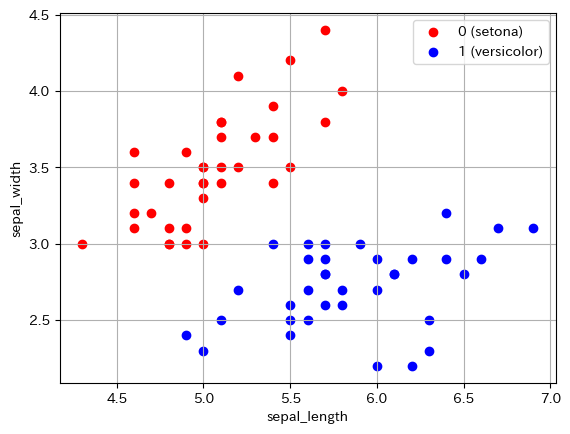

In [113]:
x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]

plt.scatter(x_t0[:, 0], x_t0[:, 1], c='r', label="0 (setona)")
plt.scatter(x_t1[:, 0], x_t1[:, 1], c='b', label="1 (versicolor)")
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.grid()
plt.show()


## 入出力次元数の定義

In [114]:
n_input = x_train.shape[1]
n_output = 1

print(n_input)
print(n_output)


2
1


## モデル定義
2値ロジスティック回帰モデル

In [115]:
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_output)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.sigmoid(x1)
        return x2

net = Net(n_input, n_output)


In [116]:
print(net)


Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [117]:
summary(net, (2, ))


Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
├─Sigmoid: 1-2                           [1]                       --
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 学習の実行

### データのテンソル化

In [118]:
inputs_train = torch.tensor(x_train, dtype=torch.float32)
inputs_test = torch.tensor(x_test, dtype=torch.float32)

labels_train = torch.tensor(y_train, dtype=torch.float32)
labels_test = torch.tensor(y_test, dtype=torch.float32)

labels1_train = labels_train.view((-1, 1))
labels1_test = labels_test.view((-1, 1))


### 初期化処理

In [119]:
lr = 0.1 # 学習率

net = Net(n_input, n_output) # 予測関数：線形関数とシグモイド関数
criterion = nn.BCELoss() # 損失関数：二値クロスエントロピー誤差
optimizer = optim.SGD(params=net.parameters(), lr=lr) # 最適化関数：確率的勾配降下法

num_epochs = 6000 # エポック数
history = np.zeros((0, 5)) # 損失記録用配列


### 計算グラフの表示

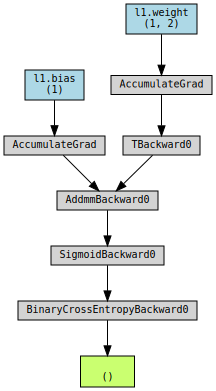

In [120]:
outputs = net(inputs_train)
loss = criterion(outputs, labels1_train)
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)


### ループ処理

In [121]:
for epoch in range(num_epochs):
    optimizer.zero_grad() # パラメータの初期化
    outputs = net(inputs_train) # 予測
    loss = criterion(outputs, labels1_train) # 損失
    loss.backward() # 勾配計算
    optimizer.step() # パラメータ更新

    train_loss = loss.item() # 訓練データにおける損失
    predicted_train = torch.where(outputs < 0.5, 0, 1) # 予測ラベル（0 or 1）
    train_acc = (predicted_train == labels1_train).sum() / len(y_train) # 正解率

    # --- 中間予測フェーズココカラ ---

    with torch.no_grad(): # 無駄な計算グラフの生成を停止
        outputs_test = net(inputs_test) # 予測
        loss = criterion(outputs_test, labels1_test) # 損失

        val_loss = loss.item()
        predicted_test = torch.where(outputs_test < 0.5, 0, 1) # 予測ラベル（0 or 1）
        val_acc = (predicted_test == labels1_test).sum() / len(y_test) # 正解率

    # --- 中間予測フェーズココマデ ---

    if (epoch % 10 == 0):
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))
        print(f"epoch: {epoch}, ")


epoch: 0, 
epoch: 10, 
epoch: 20, 
epoch: 30, 
epoch: 40, 
epoch: 50, 
epoch: 60, 
epoch: 70, 
epoch: 80, 
epoch: 90, 
epoch: 100, 
epoch: 110, 
epoch: 120, 
epoch: 130, 
epoch: 140, 
epoch: 150, 
epoch: 160, 
epoch: 170, 
epoch: 180, 
epoch: 190, 
epoch: 200, 
epoch: 210, 
epoch: 220, 
epoch: 230, 
epoch: 240, 
epoch: 250, 
epoch: 260, 
epoch: 270, 
epoch: 280, 
epoch: 290, 
epoch: 300, 
epoch: 310, 
epoch: 320, 
epoch: 330, 
epoch: 340, 
epoch: 350, 
epoch: 360, 
epoch: 370, 
epoch: 380, 
epoch: 390, 
epoch: 400, 
epoch: 410, 
epoch: 420, 
epoch: 430, 
epoch: 440, 
epoch: 450, 
epoch: 460, 
epoch: 470, 
epoch: 480, 
epoch: 490, 
epoch: 500, 
epoch: 510, 
epoch: 520, 
epoch: 530, 
epoch: 540, 
epoch: 550, 
epoch: 560, 
epoch: 570, 
epoch: 580, 
epoch: 590, 
epoch: 600, 
epoch: 610, 
epoch: 620, 
epoch: 630, 
epoch: 640, 
epoch: 650, 
epoch: 660, 
epoch: 670, 
epoch: 680, 
epoch: 690, 
epoch: 700, 
epoch: 710, 
epoch: 720, 
epoch: 730, 
epoch: 740, 
epoch: 750, 
epoch: 760, 
epoch: 770

## 学習曲線

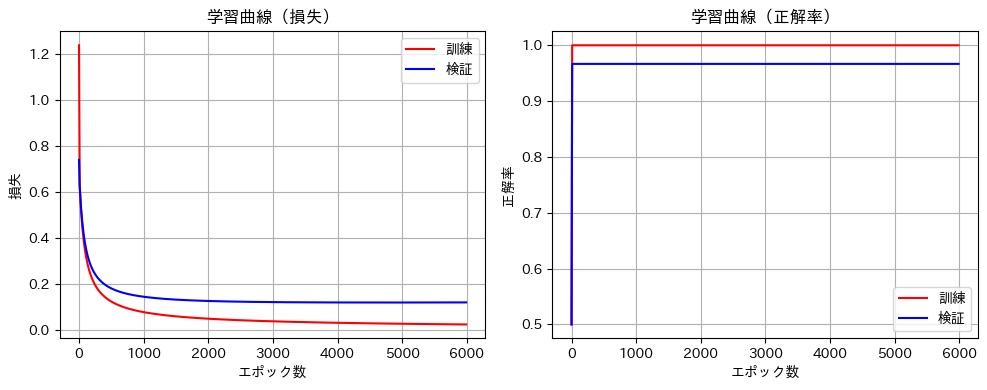

In [122]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history[:, 0], history[:, 1], c='r', label='訓練')
plt.plot(history[:, 0], history[:, 3], c='b', label='検証')
plt.title('学習曲線（損失）')
plt.xlabel('エポック数')
plt.ylabel('損失')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history[:, 0], history[:, 2], c='r', label='訓練')
plt.plot(history[:, 0], history[:, 4], c='b', label='検証')
plt.title('学習曲線（正解率）')
plt.xlabel('エポック数')
plt.ylabel('正解率')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## 決定境界
$シグモイド関数が0.5 \Leftrightarrow w_1x_1 + w_2x_2 + b = 0$
- 訓練データで描画：モデルの形を観察
- 検証データで描画：汎化性能をチェック


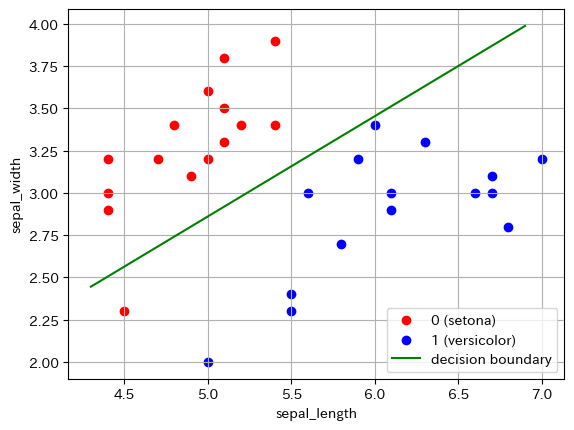

In [123]:
# x_t0 = x_train[y_train == 0]
# x_t1 = x_train[y_train == 1]
x_t0 = x_test[y_test == 0]
x_t1 = x_test[y_test == 1]
plt.scatter(x_t0[:, 0], x_t0[:, 1], c='r', label="0 (setona)")
plt.scatter(x_t1[:, 0], x_t1[:, 1], c='b', label="1 (versicolor)")

# --- 決定境界ココカラ ---

w = net.l1.weight.detach().numpy()[0]
b = net.l1.bias.detach().numpy()[0]

x0 = np.linspace(x_train[:, 0].min(), x_train[:, 0].max(), 100)
x1 = -(w[0] * x0 + b) / w[1]

plt.plot(x0, x1, c='g', label='decision boundary')

# --- 決定境界ココマデ ---

plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.grid()
plt.show()
